In [6]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, style_ax, country_handles, legend

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


*`1. indlæs og beregn andele`*

*Indlæser energiforbrugsdata fra parquet og beregner sektorandelen $s_i = \text{Energi}_i / \sum_j \text{Energi}_j$ pr. land og år.*

In [7]:
# 1. indlæs og beregn andele
df_enw = pd.read_parquet("0_intermediate/df_enw.parquet")

_excl    = {'FC_OTH_NSP_E', 'FC_TRA_NSP_E', 'FC_TRA_DAVI_E', 'FC_TRA_DNAVI_E'}
subs_enw = [s for s in var_groups.subs if s not in _excl]
countries = [g for g in var_groups.countries if g not in {'UK', 'ES'}]

df_enw = df_enw[df_enw.nrg_bal.isin(subs_enw) & df_enw.geo.isin(countries)].copy()

sectors = list(df_enw.nrg_bal.unique())

df_enw['share_pct'] = (
    df_enw['value']
    / df_enw.groupby(['geo', 'year'])['value'].transform('sum')
    * 100
)

years = np.sort(df_enw.year.unique())
df_enw.to_parquet(Path("0_intermediate") / "df_enw_share.parquet", index=False)

# Sektorandele af samlet energiforbrug

*`2. top-12 sektorer`*

*Vælger de 12 sektorer med størst EU-27-energiforbrug i seneste år som grundlag for figuren.*

In [13]:
# 2. top-12 sektorer
TOP_N = 20

last_year = int(df_enw.year.max())
subs_top = (
    df_enw[(df_enw.geo == 'EU27_2020') & (df_enw.year == last_year)]
    .set_index('nrg_bal')['value']
    .reindex(sectors, fill_value=0)
    .nlargest(TOP_N)
    .index.tolist()
)

*`3. figur: sektorandele`*

*Plotter sektorandele over tid i 4-kolonne-grid for de 12 største sektorer, én linje pr. land.*

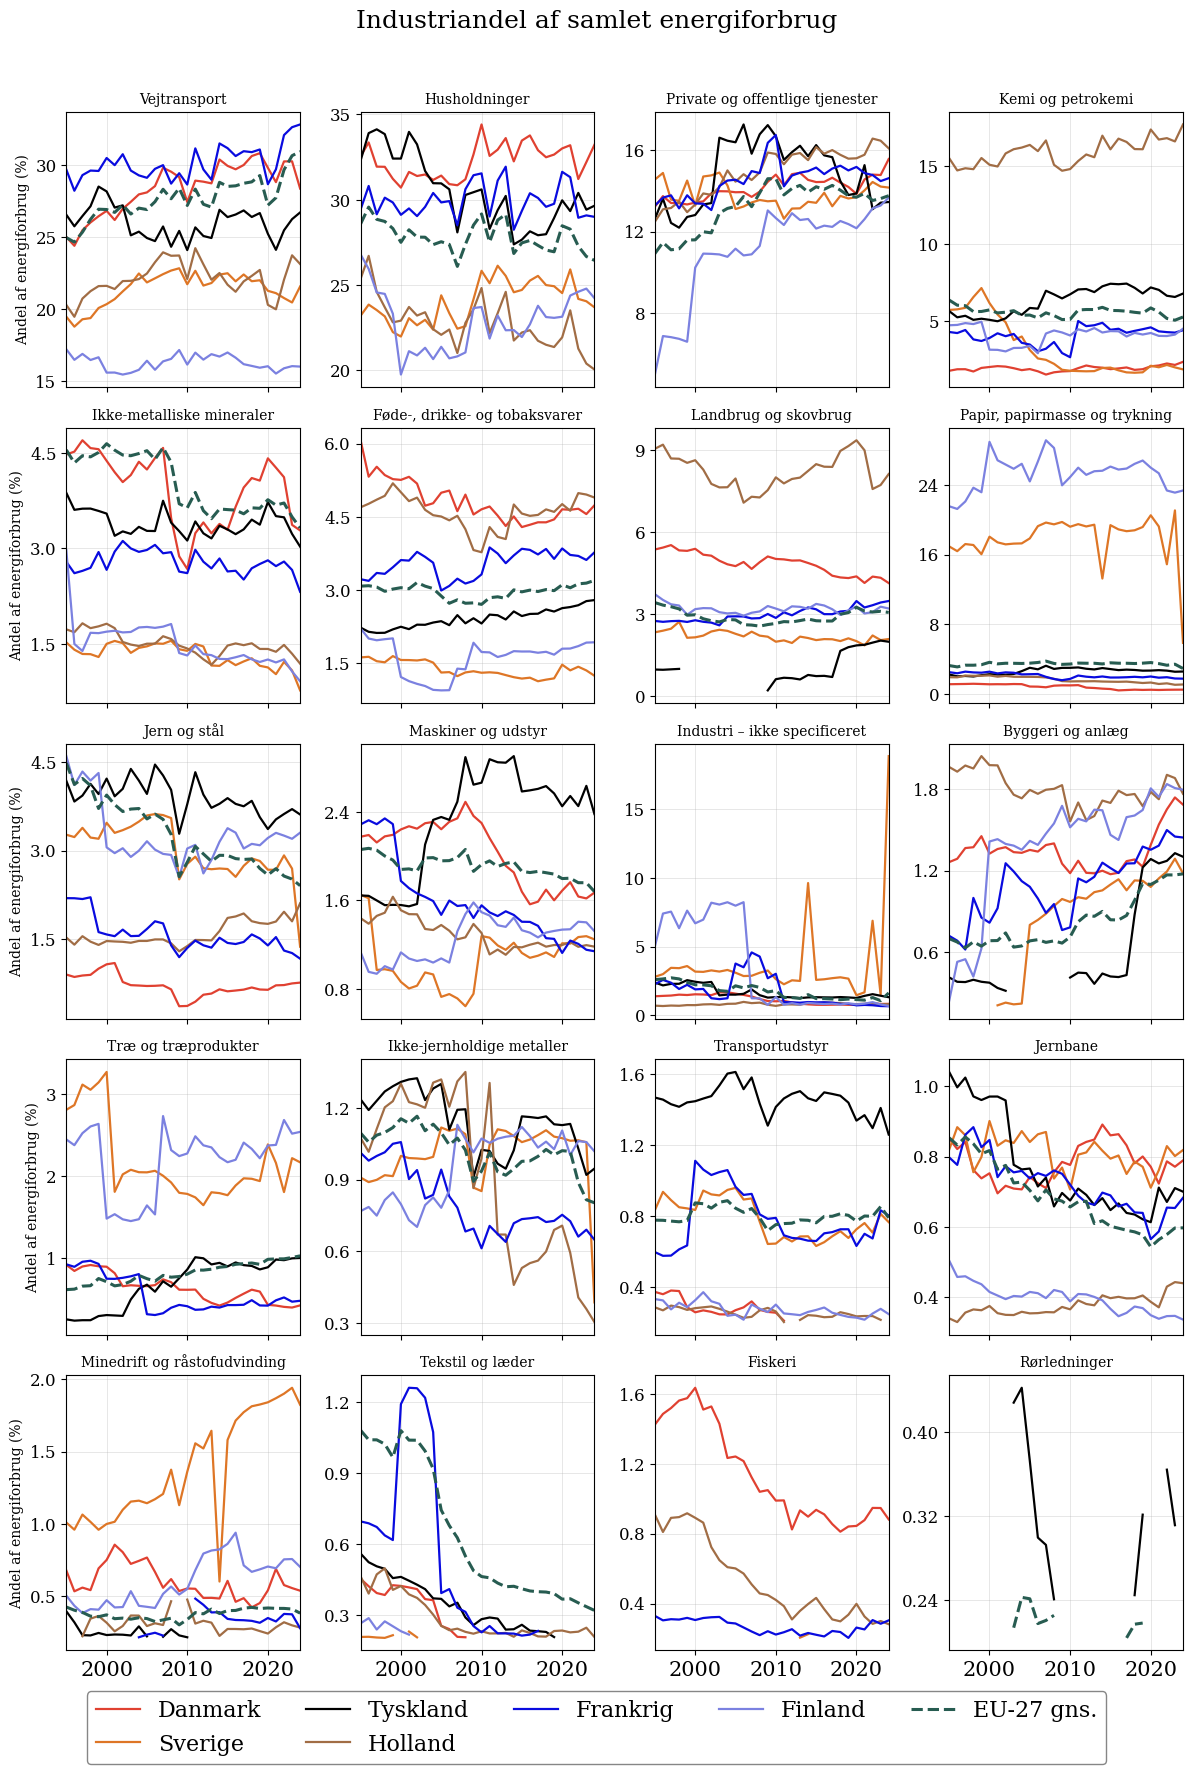

In [19]:
# 3. figur: sektorandele
NCOLS = 4
NROWS = -(-len(subs_top) // NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS,
                         figsize=(12, NROWS * 3.3),
                         sharex=True, squeeze=False)
axes_flat = axes.flatten()

for ax, sector in zip(axes_flat, subs_top):
    sub = df_enw[df_enw.nrg_bal == sector]
    for geo in countries:
        s = sub[sub.geo == geo].sort_values('year')
        if s.empty:
            continue
        s.loc[(s["share_pct"] <= 0.2) | (s["share_pct"] > 95), "share_pct"] = np.nan
        ax.plot(s.year, s.share_pct,
                color=PALETTE[geo], ls=STYLE[geo], lw=LW[geo])
    ax.set_title(var_groups.labels.get(sector, sector), fontsize=10)
    style_ax(ax, years, step=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))

for ax in axes_flat[len(subs_top):]:
    ax.set_visible(False)

for ax in axes[:, 0]:
    ax.set_ylabel('Andel af energiforbrug (%)', fontsize=10)

fig.legend(handles=country_handles(countries),
           loc='lower center',
           ncols=5,
           frameon=True, framealpha=0.95, edgecolor='0.5', fancybox=True,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Industriandel af samlet energiforbrug', y=1.02)
plt.tight_layout()
plt.show()

*`4. sanity check`*

*Verificerer at sektorandele summer til ~100 % pr. land og år.*

In [10]:
# 4. sanity check
totals = df_enw.groupby(['geo', 'year'])['share_pct'].sum()
summary = totals.groupby('geo').agg(['min', 'max']).round(2)
assert (summary['min'] > 99.0).all() and (summary['max'] < 101.0).all(), \
    "Andele summer ikke til ~100 %!"
print("✓ Alle landes sektorer summer til ~100 % (min/max pr. land):")
summary

✓ Alle landes sektorer summer til ~100 % (min/max pr. land):


,min,max
geo,,
DE,100.0,100.0
DK,100.0,100.0
EU27_2020,100.0,100.0
FI,100.0,100.0
FR,100.0,100.0
NL,100.0,100.0
SE,100.0,100.0
